<a href="https://colab.research.google.com/github/ashwinisonawane24/Ashwini-sonawane/blob/main/Project1_Uber_SmartPricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/uber-fares-dataset")

print("Path to dataset files:", path)

100%|██████████| 7.04M/7.04M [00:00<00:00, 93.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/yasserh/uber-fares-dataset/versions/1


In [3]:
import os

# Find the actual csv file inside the folder
path = "/root/.cache/kagglehub/datasets/yasserh/uber-fares-dataset/versions/1"

# List all files in that folder
print("Files in folder:")
for file in os.listdir(path):
    print(file)

Files in folder:
uber.csv


In [4]:
# Add the actual filename at the end
df = pd.read_csv(path + '/uber.csv')

print("Dataset loaded!")
print("Shape:", df.shape)

Dataset loaded!
Shape: (200000, 9)


**df.shape** tells you how many rows and columns exist

In [5]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [6]:
print(df.columns.tolist())

['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']


1) **df.columns** ----->This gives you all column names of the DataFrame.
But it’s not a normal list - it’s a special object called an Index

2) **.tolist(**) ----> This converts the Index object → Python list

In [7]:
print(df.dtypes)

Unnamed: 0             int64
key                   object
fare_amount          float64
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object


In [8]:
print(df.isnull().sum())

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64


In [9]:
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [10]:
# How many rides are in this dataset?

print('Total rides:', len(df))

Total rides: 200000


In [11]:
# What's the average fare?
print("Average fare: $", round(df['fare_amount'].mean(), 2))

Average fare: $ 11.36


In [12]:
print("Max fare: $", df['fare_amount'].max())

Max fare: $ 499.0


My Day 1 Observations:
1. Total rows & columns = The dataset contains 20,0000 rows and 9 columns, sufficient for initial analysis.

2. Columns with missing values = Missing values are present in dropoff_latitude and dropoff_longitude, which may affect location-based analysis.

3. Average fare =  The average fare is approximately $11.36, suggesting most rides are short-distance.

4. Any weird values I noticed =  Some fare values are negative (e.g., -52), which are invalid and indicate data quality issues.

5. One question I have about this data = this data has low missing value rate like clean data

In [13]:
print(df.isnull().sum())
print("\nMissing %")
print(round(df.isnull().sum() / len(df) * 100, 2))

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

Missing %
Unnamed: 0           0.0
key                  0.0
fare_amount          0.0
pickup_datetime      0.0
pickup_longitude     0.0
pickup_latitude      0.0
dropoff_longitude    0.0
dropoff_latitude     0.0
passenger_count      0.0
dtype: float64


In [14]:
# Negative fare amount noticed


print("Negative fares:", df[df['fare_amount']<0].shape[0])

print("Positive fares:", df[df['fare_amount']>0].shape[0])

print("Zero fares:", df[df['fare_amount']==0].shape[0])

print("Fares above $200:", df[df['fare_amount']>200].shape[0])

Negative fares: 17
Positive fares: 199978
Zero fares: 5
Fares above $200: 7


In [15]:
# Are coordinates valid? (lat should be -90 to 90)

print(df[df['pickup_latitude']>90].shape[0])
print(df[df['pickup_latitude']<-90].shape[0])

4
0


In [16]:
# Any duplicate rides?

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [17]:
# Is datetime in correct format?

print(df['pickup_datetime'].dtype)
print(df['pickup_datetime'].head())

object
0    2015-05-07 19:52:06 UTC
1    2009-07-17 20:04:56 UTC
2    2009-08-24 21:45:00 UTC
3    2009-06-26 08:22:21 UTC
4    2014-08-28 17:47:00 UTC
Name: pickup_datetime, dtype: object


1) Negative fares     = 17       ← impossible in real world, must remove

2) Zero fares         = 5        ← also invalid, remove these too

3) Fares above $200   = 7        ← possible but suspicious, investigate

4) Invalid latitude   = 4        ← coordinates outside earth range!

5) Duplicate rows     = 0        ← clean ✅

6) Missing values     = only 1   ← almost clean ✅

7) Datetime format    = object   ← needs conversion to datetime

# Section 2 — SQL Analysis

In [18]:
import sqlite3
import pandas as pd

In [19]:
conn = sqlite3.connect(':memory:')    #':memory:' → database is stored in RAM (not saved on disk)
                                      #“Create a blank SQL database for me, just for this session”

In [20]:
df.to_sql('uber', conn, index=False, if_exists='replace')

200000

Let’s break it:

df → your Pandas dataframe (Uber dataset)
.to_sql() → converts dataframe into a SQL table
Parameters:
'uber' → name of the SQL table
conn → where to store it (your database)
index=False → don’t include row numbers as a column
if_exists='replace' → if table already exists, delete and recreate

📌 Simple meaning:

“Take my dataframe and store it as a SQL table called uber”

In [21]:
print("✅ SQL Database ready!")
print("Table name: uber")


print("Total rows:", pd.read_sql_query("SELECT COUNT(*) as total FROM uber", conn).values[0][0])


✅ SQL Database ready!
Table name: uber
Total rows: 200000


In [22]:
# Convert datetime column
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], utc=True)

In [23]:
df['hour']= df['pickup_datetime'].dt.hour

df['day_of_week'] = df['pickup_datetime'].dt.day_name()

df['month']= df['pickup_datetime'].dt.month

df['year']= df['pickup_datetime'].dt.year

In [24]:
# Reload into SQL with new columns

df.to_sql('uber', conn, index=False, if_exists='replace')

print("Datetime columns added!")
print(df[['pickup_datetime','hour','day_of_week','month', 'year']].head())

Datetime columns added!
            pickup_datetime  hour day_of_week  month  year
0 2015-05-07 19:52:06+00:00    19    Thursday      5  2015
1 2009-07-17 20:04:56+00:00    20      Friday      7  2009
2 2009-08-24 21:45:00+00:00    21      Monday      8  2009
3 2009-06-26 08:22:21+00:00     8      Friday      6  2009
4 2014-08-28 17:47:00+00:00    17    Thursday      8  2014


In [25]:
#Query 1: Ride Demand by Hour


query1 = """

SELECT
    hour,
    COUNT(*) as total_rides,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM uber), 2) as demand_percentage
FROM uber
GROUP BY hour
ORDER BY total_rides DESC
LIMIT 10

"""

result = pd.read_sql_query(query1, conn)
print("Top 10 Busiest Hours:")
print(result)


Top 10 Busiest Hours:
   hour  total_rides  demand_percentage
0    19        12605               6.30
1    18        12072               6.04
2    20        11755               5.88
3    21        11446               5.72
4    22        11023               5.51
5    13        10024               5.01
6    12         9924               4.96
7    23         9805               4.90
8    17         9758               4.88
9    14         9749               4.87


**SO WHAT**
1) Hour 18 (6PM) and Hour 19 (7PM) represent the highest
2) ride demand of the day ----> indicating a strong evening
3) commute pattern driving peak utilization

**NOW WHAT**
1) Uber should proactively deploy 20-30% more drivers
2) between 5PM-8PM and introduce surge pricing during
3) this window to maximize revenue capture

**WHAT IF ignored**
1) Driver shortage during peak hours leads to longer
2) wait times, increased cancellations, and riders
3) switching to competitors — directly impacting
4) evening revenue which likely represents 20%+ of daily earnings

In [26]:
#Query 2) Average Fare Per Hour

In [27]:
query2= ('''

select hour,
round(AVG(fare_amount), 2) as avg_fare,
round(min(fare_amount), 2) as min_fare,
round(max(fare_amount), 2) as max_fare,
count(*) as total_rides

from uber
where fare_amount > 0
group by hour
order by avg_fare desc
''')


result = pd.read_sql_query(query2, conn)

print('Average Fare Per Hour')
print(result)

Average Fare Per Hour
    hour  avg_fare  min_fare  max_fare  total_rides
0      5     16.02      2.50    131.93         1966
1      4     14.14      2.50    499.00         2364
2     14     11.98      2.50    150.83         9748
3     15     11.94      2.50    126.10         9613
4      6     11.92      2.50    106.50         4139
5     16     11.79      0.01    200.00         8313
6      3     11.73      2.50    160.00         3254
7      1     11.66      2.50    171.35         5908
8      0     11.66      2.50    275.00         7844
9     23     11.58      2.50    190.83         9802
10    17     11.49      2.50    111.75         9758
11    13     11.48      2.50    150.00        10024
12     2     11.45      2.50    130.00         4421
13    22     11.31      2.50    206.38        11022
14    11     11.19      2.50    112.15         9422
15    12     11.17      2.50    220.00         9924
16     7     11.13      2.50    127.50         7229
17    10     11.03      2.50    137.00    

SO WHAT?

**1) Two distinct fare patterns exist:**

Early morning (5AM) = highest avg fare ($X)

→ Long distance trips (airport/outstation)

→ Low volume but high value per ride

Evening hours (17-20) = highest ride volume

→ Short distance office commutes

 → High volume but moderate fare per ride

NOW WHAT?

**2) Uber needs TWO different pricing strategies:**

Strategy 1 → Early morning: premium pricing for long distance rides

Strategy 2 → Evening: surge pricing for volume to maximize total revenue

WHAT IF ignored?

**3) Treating all hours with same pricing** = leaving money on table during BOTH windowsv= estimated 25% revenue underperformance


In [28]:
query_verify = """
SELECT
    CASE
        WHEN hour BETWEEN 4 AND 6 THEN 'Early Morning (4-6AM)'
        WHEN hour BETWEEN 17 AND 20 THEN 'Evening Peak (5-8PM)'
        ELSE 'Other Hours'
    END as time_slot,
    COUNT(*) as total_rides,
    ROUND(AVG(fare_amount), 2) as avg_fare,
    ROUND(SUM(fare_amount), 2) as total_revenue
FROM uber
WHERE fare_amount > 0
GROUP BY time_slot
ORDER BY total_revenue DESC
"""

result_verify = pd.read_sql_query(query_verify, conn)
print("Early Morning vs Evening Comparison:")
print(result_verify)

Early Morning vs Evening Comparison:
               time_slot  total_rides  avg_fare  total_revenue
0            Other Hours       145322     11.38     1653992.48
1   Evening Peak (5-8PM)        46187     10.91      504028.18
2  Early Morning (4-6AM)         8469     13.49      114259.26


early_morning_revenue = 114259.26

evening_revenue = 504028.18

other_revenue = 1653992.48

total_revenue = early_morning_revenue + evening_revenue + other_revenue

In [29]:
early_morning_revenue = 114259.26
evening_revenue = 504028.18
other_revenue = 1653992.48
total_revenue = early_morning_revenue + evening_revenue + other_revenue

print("Revenue Breakdown:")
print(f"Early Morning = ${early_morning_revenue:,.2f} → {round(early_morning_revenue/total_revenue*100, 1)}% of total")
print(f"Evening Peak  = ${evening_revenue:,.2f} → {round(evening_revenue/total_revenue*100, 1)}% of total")
print(f"Other Hours   = ${other_revenue:,.2f} → {round(other_revenue/total_revenue*100, 1)}% of total")
print(f"Total Revenue = ${total_revenue:,.2f}")

Revenue Breakdown:
Early Morning = $114,259.26 → 5.0% of total
Evening Peak  = $504,028.18 → 22.2% of total
Other Hours   = $1,653,992.48 → 72.8% of total
Total Revenue = $2,272,279.92


Evening Peak (5-8PM):

→ Only 23% of total rides

→ BUT generates $504K revenue

→ With smart surge pricing

   even 10% fare increase = $50,000 extra revenue!

Early Morning (4-6AM):

→ Only 4% of total rides

→ Highest fare per ride = $13.49

→ These are premium customers

→ Can charge even more = airport/luxury pricing

In [30]:
query3 = """
SELECT
    CASE
        WHEN hour BETWEEN 7 AND 10 THEN 'Morning Peak'
        WHEN hour BETWEEN 16 AND 20 THEN 'Evening Peak'
        ELSE 'Non Peak'
    END as time_category,
    COUNT(*) as total_rides,
    ROUND(AVG(fare_amount), 2) as avg_fare,
    ROUND(SUM(fare_amount), 2) as total_revenue
FROM uber
WHERE fare_amount > 0
GROUP BY time_category
ORDER BY total_revenue DESC
"""

result3 = pd.read_sql_query(query3, conn)
print("Peak vs Non-Peak Analysis:")
print(result3)

Peak vs Non-Peak Analysis:
  time_category  total_rides  avg_fare  total_revenue
0      Non Peak       110895     11.63     1289946.53
1  Evening Peak        54500     11.05      602071.09
2  Morning Peak        34583     11.00      380262.30


In [31]:
# Peak Hours Analysis (Simple Version)

# Step 1: Define rides
morning_peak = 34583
evening_peak = 54500
non_peak = 110895

# Step 2: Define revenue
morning_rev = 380262.30
evening_rev = 602071.09
non_peak_rev = 1289946.53

# Step 3: Calculate total rides
peak_rides = morning_peak + evening_peak
total_rides = peak_rides + non_peak

# Step 4: Calculate percentages
peak_percentage = (peak_rides / total_rides) * 100

# Step 5: Calculate revenue
peak_rev = morning_rev + evening_rev
total_rev = peak_rev + non_peak_rev
peak_rev_pct = (peak_rev / total_rev) * 100

# Step 6: Print results
print("Peak rides:", peak_rides)
print("Peak ride %:", round(peak_percentage, 1))

print("Peak revenue:", round(peak_rev, 2))
print("Peak revenue %:", round(peak_rev_pct, 1))

print("\n KEY INSIGHT:")
print("Peak hours =", round(peak_percentage,1),
      "% of rides but only",
      round(peak_rev_pct,1), "% of revenue")

print("This means peak hours are UNDERPERFORMING!")


# Step 7: Surge opportunity
print("10% surge:", round(peak_rev * 0.10, 2))
print("15% surge:", round(peak_rev * 0.15, 2))
print("20% surge:", round(peak_rev * 0.20, 2))

Peak rides: 89083
Peak ride %: 44.5
Peak revenue: 982333.39
Peak revenue %: 43.2

 KEY INSIGHT:
Peak hours = 44.5 % of rides but only 43.2 % of revenue
This means peak hours are UNDERPERFORMING!
10% surge: 98233.34
15% surge: 147350.01
20% surge: 196466.68


In [32]:
query4 = """
SELECT
    day_of_week,
    COUNT(*) as total_rides,
    ROUND(AVG(fare_amount), 2) as avg_fare,
    ROUND(SUM(fare_amount), 2) as total_revenue
FROM uber
WHERE fare_amount > 0
GROUP BY day_of_week
ORDER BY total_rides DESC
"""

result4 = pd.read_sql_query(query4, conn)
print("📅 Rides by Day of Week:")
print(result4)

📅 Rides by Day of Week:
  day_of_week  total_rides  avg_fare  total_revenue
0      Friday        30874     11.44      353351.20
1    Saturday        30250     11.03      333737.30
2    Thursday        30018     11.52      345784.72
3   Wednesday        29034     11.35      329622.78
4     Tuesday        28121     11.08      311648.10
5      Sunday        26439     11.76      310855.63
6      Monday        25242     11.38      287280.19


Best day    = Friday   → highest rides + good fare

Worst day   = Monday   → lowest revenue, needs discounts

Premium day = Sunday   → fewer rides but highest fare ($11.76)

Weird day   = Saturday → 2nd most rides but cheapest fare

In [33]:
query5 = """
SELECT
    hour,
    COUNT(*) as total_rides,
    ROUND(AVG(fare_amount), 2) as avg_fare,
    ROUND(SUM(fare_amount), 2) as total_revenue,
    ROUND(SUM(fare_amount) * 100.0 /
         (SELECT SUM(fare_amount) FROM uber
          WHERE fare_amount > 0), 2)
         as revenue_percentage
FROM uber
WHERE fare_amount > 0
GROUP BY hour
ORDER BY total_revenue DESC
LIMIT 5
"""

result5 = pd.read_sql_query(query5, conn)
print("Top 5 Revenue Generating Hours:")
print(result5)

Top 5 Revenue Generating Hours:
   hour  total_rides  avg_fare  total_revenue  revenue_percentage
0    19        12604     10.57      133195.33                5.86
1    18        12071     10.92      131816.00                5.80
2    20        11754     10.80      126932.69                5.59
3    21        11444     10.96      125448.03                5.52
4    22        11022     11.31      124636.91                5.49


**TOP 5 REVENUE HOURS**
1) 7PM, 6PM, 8PM, 9PM, 10PM = all evening
2) These 5 hours = 28.3% of total revenue
3) 10PM = lowest rides but highest fare


**Action = Surge pricing 6PM-10PM window**

Finding 1 → 6PM-7PM = busiest hours
            Deploy more drivers by 5PM

Finding 2 → 5AM = highest fare ($13.49)
            Airport/long distance trips

Finding 3 → Non peak fare > Peak fare
            Uber UNDERCHARGING at busy hours
            10% surge = $98,233 extra revenue

Finding 4 → Friday = best revenue day
            Monday = worst, needs discounts
            Sunday = premium airport rides

Finding 5 → 6PM-10PM = 28.3% of total revenue
            Just 5 hours drive 28% of revenue!

PROBLEM  → Uber undercharges during peak hours

EVIDENCE → Non peak ($11.63) > Peak ($11.05)

SOLUTION → Smart dynamic pricing engine

IMPACT   → 15-20% revenue improvement

In [34]:
df.head(2)

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day_of_week,month,year
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,19,Thursday,5,2015
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,20,Friday,7,2009


# Section 3 — SQL Analysis Part 2

In [35]:
#Query 1: Passenger Count Analysis

query= '''

select passenger_count,
count(*) as total_rides,
round(avg(fare_amount), 2) as avg_fare,
round(sum(fare_amount), 2) as total_revenue,
ROUND(COUNT(*) * 100.0 /
         (SELECT COUNT(*) FROM uber), 2) as ride_percentage

from uber
where fare_amount > 0 and passenger_count > 0
group by passenger_count
order by total_rides desc

'''

result = pd.read_sql_query(query, conn)
print("Passenger Count Analysis:")
print(result)


Passenger Count Analysis:
   passenger_count  total_rides  avg_fare  total_revenue  ride_percentage
0                1       138414     11.26     1557905.96            69.21
1                2        29424     11.79      346799.14            14.71
2                5        14005     11.21      157050.14             7.00
3                3         8878     11.50      102093.56             4.44
4                4         4276     11.64       49783.21             2.14
5                6         4271     12.16       51929.11             2.14
6              208            1     11.70          11.70             0.00


so what?
1) passenger count 1 has highest percentage and more revenue

(which means, person may be travel solo for office, and total revenue is also highest)

so we have to check timimg of solo travel


2) the passenger count 208, it look like inorrect data

In [36]:
query_solo= '''

select hour,
count(*) as solo_rides,
round(avg(fare_amount), 2) as avg_fare,
round(sum(fare_amount), 2) as total_revenue

from uber
where fare_amount >0 and passenger_count = 1
group by hour
order by solo_rides desc

'''

result_solo = pd.read_sql_query(query_solo, conn)
print("Solo Rides by Hour:")
print(result_solo)


Solo Rides by Hour:
    hour  solo_rides  avg_fare  total_revenue
0     19        8530     10.57       90197.52
1     18        8126     10.81       87857.59
2     20        7876     10.76       84752.66
3     21        7620     11.02       83995.49
4     22        7306     11.41       83396.55
5      9        7082     10.80       76480.16
6     13        6987     11.10       77553.23
7     12        6957     10.99       76466.37
8      8        6880     10.76       74013.81
9     14        6818     11.69       79702.39
10    11        6676     11.04       73719.31
11    17        6627     11.22       74373.76
12    15        6578     11.70       76953.65
13    10        6484     10.81       70066.90
14    23        6335     11.74       74364.58
15    16        5730     11.76       67401.61
16     7        5650     10.92       61672.81
17     0        5041     11.74       59179.30
18     1        3823     11.71       44753.57
19     6        3286     11.59       38084.97
20     2      

**SOLO RIDER TIMING ANALYSIS**

Evening (7PM-10PM)  = highest volume

                    = short office commutes
                    = avg fare $10.57-$11.41
                    → Apply surge pricing

Night (11PM-2AM)    = moderate volume

                    = safety rides
                    = avg fare $11.71-$11.74
                    → Safety guarantee marketing

Early AM (4AM-5AM)  = lowest volume

                    = airport trips
                    = avg fare $14.10-$15.78!
                    → Premium airport tier

KEY INSIGHT:

5AM fare ($15.78) = 49% higher than 7PM ($10.57)
Early morning = most valuable solo rides


In [37]:
#Query 2 — Yearly Revenue Trend!

query2='''

select year,
count(*) as total_rides,
round(avg(fare_amount), 2) as avg_fare,
round(sum(fare_amount), 2) as total_revenue

from uber
where fare_amount > 0
group by year
order by year

'''

result2 = pd.read_sql_query(query2, conn)
print("Yearly Revenue Trend:")
print(result2)

Yearly Revenue Trend:
   year  total_rides  avg_fare  total_revenue
0  2009        30536     10.01      305637.75
1  2010        30185     10.14      306160.42
2  2011        31945     10.40      332326.24
3  2012        32396     11.21      363298.45
4  2013        31195     12.71      396489.39
5  2014        29968     13.02      390094.57
6  2015        13753     12.96      178273.10


2009-2012 → rides increasing + fare increasing

2013 onwards → rides decreasing

2015 → lowest rides but high avg fare (may be due to incomplete data lets check 2015 data)



In [38]:
# Verify 2015 data

query_2015 = """
SELECT
    month,
    COUNT(*) as rides
FROM uber
WHERE year = 2015
AND fare_amount > 0
GROUP BY month
ORDER BY month
"""

result_2015 = pd.read_sql_query(query_2015, conn)

print(" 2015 Monthly Breakdown:")

print(result_2015)

 2015 Monthly Breakdown:
   month  rides
0      1   2229
1      2   2221
2      3   2360
3      4   2338
4      5   2445
5      6   2160


Dataset stops at June 2015!
Only 6 months out of 12
= incomplete year

In [39]:
monthly_2015 = 2229 + 2221 + 2360 + 2338 + 2445 + 2160
full_year_estimate = monthly_2015 * 2  # 6 months x2

print("2015 actual rides (6 months):", monthly_2015)
print("2015 estimated full year:", full_year_estimate)
print("2014 actual rides:", 29968)
print("Difference:", full_year_estimate - 29968)

2015 actual rides (6 months): 13753
2015 estimated full year: 27506
2014 actual rides: 29968
Difference: -2462


**2015 DATA CLARIFICATION:**

Dataset only contains Jan-June 2015

6 months data = 13,753 rides

Estimated full year = ~27,500 rides vs 2014 actual = 29,968 rides

Real decline = only ~8% not 54%!


**CONCLUSION:**

2015 drop was data incompleteness

NOT business collapse

Competition impact = mild ~8% ride decline

Uber maintained premium pricing throughout


In [40]:
#Query 3 — Monthly Demand Patterns!

query3='''

select month,
count(*) as total_rides,
round(avg(fare_amount), 2) as avg_fare,
round(sum(fare_amount), 2) as total_revenue

from uber
where fare_amount > 0 and year !=2015
group by month
order by month asc

'''

result3 = pd.read_sql_query(query3, conn)

print("Monthly Demand Patterns:")

print(result3)

Monthly Demand Patterns:
    month  total_rides  avg_fare  total_revenue
0       1        15438     10.53      162539.25
1       2        14466     10.67      154403.34
2       3        16396     10.85      177948.01
3       4        16267     11.12      180936.00
4       5        16410     11.40      187002.18
5       6        15626     11.33      177081.87
6       7        15095     11.16      168478.59
7       8        14221     11.21      159351.40
8       9        15266     11.79      180011.21
9      10        16212     11.72      190058.67
10     11        15312     11.61      177806.02
11     12        15516     11.50      178390.28


**QUERY 3 - MONTHLY PATTERNS**

Peak months    = March, April, May, October

Reason         = Spring travel + Fall holidays

Summer peak (Mar-May):
1) Spring break + tourist season
2) Avg fare climbs from 10.85 to 11.40

Fall peak (Sep-Oct):

1) Back to office + Halloween events
2) October = highest revenue month ($190,058)

Slow months = February, August
1) Cold/vacation periods = less city rides

RECOMMENDATION:
1) Increase driver incentives in peak months
2) Offer promotions in Feb/Aug to boost demand
3) Seasonal surge pricing for Mar/May/Oct


In [41]:
# Monthly revenue data
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']

revenue = [162539, 154403, 177948,
           180936, 187002, 177081,
           168478, 159351, 180011,
           190058, 177806, 178390]

# total and average
total = sum(revenue)
avg = total / 12

print("Total revenue:", total)
print("Average per month:", round(avg))

# best and worst
print("Best month revenue:", max(revenue))
print("Worst month revenue:", min(revenue))
print("Difference:", max(revenue) - min(revenue))

# checking months
for i in range(12):
    if revenue[i] > avg:
        print(months[i], "- above average")
    else:
        print(months[i], "- below average")

Total revenue: 2094003
Average per month: 174500
Best month revenue: 190058
Worst month revenue: 154403
Difference: 35655
Jan - below average
Feb - below average
Mar - above average
Apr - above average
May - above average
Jun - above average
Jul - below average
Aug - below average
Sep - above average
Oct - above average
Nov - above average
Dec - above average


MONTHLY REVENUE SUMMARY

Total annual revenue  = $2,094,003

Monthly average       = $174,500



Slow months (4) = Jan, Feb, Jul, Aug


1) Winter + late summer = less travel

2) Strategy = promotional discounts

Peak months (8) = Mar-Jun, Sep-Dec
1) Spring + Fall + Holidays = busy
2) Strategy = surge pricing

Revenue gap = $35,655 (Oct vs Feb)

**Opportunity = recover ~$60,000 annually through targeted slow month promotions**


In [42]:
# Query 4 — Trip Category Analysis

query4 = '''

select
case
    when fare_amount between 0 and 10
    then 'Short Trip (0-10)'
    when fare_amount between 10 and 20
    then 'Medium Trip (10-20)'
    when fare_amount between 20 and 50
    then 'Long Trip (20-50)'
    when fare_amount > 50
    then 'Premium Trip (50+)'
end as trip_category,
count(*) as total_rides,
round(avg(fare_amount),2) as avg_fare,
round(sum(fare_amount),2) as total_revenue,
round(count(*)*100.0/(select count(*) from uber)) as percentage
from uber
where fare_amount > 0
group by trip_category
order by total_rides desc

'''

result4 = pd.read_sql_query(query4, conn)

print("Trip Category Analysis:")

print(result4)


Trip Category Analysis:
         trip_category  total_rides  avg_fare  total_revenue  percentage
0    Short Trip (0-10)       124944      6.60      824921.64        62.0
1  Medium Trip (10-20)        54635     13.57      741163.62        27.0
2    Long Trip (20-50)        17793     30.64      545243.09         9.0
3   Premium Trip (50+)         2606     61.76      160951.57         1.0


In [43]:
# Run this quick calculation
short_per_ride = round(824921 / 124944, 2)
premium_per_ride = round(160951 / 2606, 2)

print("Revenue per ride:")
print(f"Short Trip   → ${short_per_ride} per ride")
print(f"Premium Trip → ${premium_per_ride} per ride")
print(f"Premium earns {round(premium_per_ride/short_per_ride, 1)}x more per ride!")

Revenue per ride:
Short Trip   → $6.6 per ride
Premium Trip → $61.76 per ride
Premium earns 9.4x more per ride!


In [44]:
# If premium grows from 1% to 3%
current_premium = 2606
target_premium = 6000  # roughly 3%
avg_premium_fare = 61.76

current_revenue = current_premium * avg_premium_fare
target_revenue = target_premium * avg_premium_fare
extra_revenue = target_revenue - current_revenue

print("Current premium revenue:", round(current_revenue))
print("Target premium revenue:", round(target_revenue))
print("Extra revenue opportunity:", round(extra_revenue))

Current premium revenue: 160947
Target premium revenue: 370560
Extra revenue opportunity: 209613


**QUERY 4 — TRIP CATEGORY FINDINGS**

RIGHT strategy:

Short trips   = surge pricing (volume play)

Premium trips = quality experience (value play)

corporate accounts, airport dedicated service

**OPPORTUNITY:**

1) Growing premium from 1% to 3%
2) ~$241,000 additional revenue


In [45]:
query5 = """
SELECT
    CASE
        WHEN hour BETWEEN 4 AND 6
            THEN 'Early Morning'
        WHEN hour BETWEEN 7 AND 10
            THEN 'Morning Peak'
        WHEN hour BETWEEN 11 AND 15
            THEN 'Afternoon'
        WHEN hour BETWEEN 16 AND 20
            THEN 'Evening Peak'
        WHEN hour BETWEEN 21 AND 23
            THEN 'Late Night'
        ELSE 'Midnight'
    END as time_slot,
    CASE
        WHEN fare_amount BETWEEN 0 AND 10
            THEN 'Short'
        WHEN fare_amount BETWEEN 10 AND 20
            THEN 'Medium'
        ELSE 'Long/Premium'
    END as trip_type,
    COUNT(*) as total_rides,
    ROUND(AVG(fare_amount), 2) as avg_fare
FROM uber
WHERE fare_amount > 0
GROUP BY time_slot, trip_type
ORDER BY total_rides DESC
"""

result5 = pd.read_sql_query(query5, conn)

print("Time Slot vs Trip Type:")

print(result5)

Time Slot vs Trip Type:
        time_slot     trip_type  total_rides  avg_fare
0    Evening Peak         Short        34830      6.62
1       Afternoon         Short        30813      6.61
2    Morning Peak         Short        22325      6.56
3      Late Night         Short        19762      6.68
4    Evening Peak        Medium        14692     13.43
5       Afternoon        Medium        12750     13.49
6        Midnight         Short        12271      6.59
7      Late Night        Medium         9310     13.67
8    Morning Peak        Medium         9068     13.48
9        Midnight        Medium         6772     13.89
10      Afternoon  Long/Premium         5168     36.24
11   Evening Peak  Long/Premium         4978     34.98
12  Early Morning         Short         4943      6.31
13     Late Night  Long/Premium         3196     32.64
14   Morning Peak  Long/Premium         3190     34.95
15       Midnight  Long/Premium         2384     31.16
16  Early Morning        Medium         2

Persona 1 (Commuter):

1) Surge pricing during peak hours

2) Subscription plan (weekly pass)

3) "Ride 5 days get 1 free" loyalty


Persona 2 (Social):

1) Group ride discounts

2) Weekend special pricing

3) Restaurant partnerships

Persona 3 (Premium):

1) Priority driver matching
2) Corporate account packages
3) Airport dedicated fleet
4) Premium tier pricing

#Data Cleaning & Feature Engineering

 Step 1) Remove Unnecessary Columns

In [46]:
# Add text cell first
# Section 4 — Data Cleaning & Feature Engineering

# Unnamed:0 and key columns are not needed
# Unnamed:0 = just row number
# key = just timestamp duplicate

print("Before:", df.shape)

df = df.drop(['Unnamed: 0', 'key'], axis=1)

print("After:", df.shape)
print("Removed 2 unnecessary columns ✅")

Before: (200000, 13)
After: (200000, 11)
Removed 2 unnecessary columns ✅


Step 2) Fix Missing Values

In [47]:
# We found 1 missing dropoff location
print("Missing before:", df.isnull().sum().sum())

# Remove rows with missing values
df = df.dropna()

print("Missing after:", df.isnull().sum().sum())
print("Shape after:", df.shape)
print("Removed missing rows ✅")

Missing before: 2
Missing after: 0
Shape after: (199999, 11)
Removed missing rows ✅


 Step 3) Remove Invalid Fares

In [48]:
print("Before fare cleaning:", df.shape)

# Remove negative fares (17 rows)
# Remove zero fares (5 rows)
# Remove fares above $200 (7 rows)
df = df[df['fare_amount'] > 0]
df = df[df['fare_amount'] <= 200]

print("After fare cleaning:", df.shape)

# How many removed?
removed = 200000 - df.shape[0]
print(f"Total removed so far: {removed} rows")

Before fare cleaning: (199999, 11)
After fare cleaning: (199970, 11)
Total removed so far: 30 rows


Step 4) Remove Invalid Coordinates

In [49]:
print("Before coordinate cleaning:", df.shape)

# Valid ranges:
# Latitude  = -90 to 90
# Longitude = -180 to 180

df = df[
    (df['pickup_latitude'].between(-90, 90)) &
    (df['pickup_longitude'].between(-180, 180)) &
    (df['dropoff_latitude'].between(-90, 90)) &
    (df['dropoff_longitude'].between(-180, 180))
]

# Remove coordinates that are exactly 0
# (means no GPS data recorded)
df = df[
    (df['pickup_latitude'] != 0) &
    (df['pickup_longitude'] != 0) &
    (df['dropoff_latitude'] != 0) &
    (df['dropoff_longitude'] != 0)
]

print("After coordinate cleaning:", df.shape)

Before coordinate cleaning: (199970, 11)
After coordinate cleaning: (195996, 11)


Step 5) Fix Passenger Count

In [50]:
print("Before passenger cleaning:", df.shape)

# Remove passenger count = 0 (invalid)
# Remove passenger count = 208 (dirty data)
# Keep only 1-6 passengers (valid car capacity)
df = df[df['passenger_count'].between(1, 6)]

print("After passenger cleaning:", df.shape)
print("passenger_count 208 removed")

Before passenger cleaning: (195996, 11)
After passenger cleaning: (195309, 11)
passenger_count 208 removed


In [51]:
# Cleaning Summary
initial_rows = 200000
clean_rows = df.shape[0]
removed_rows = initial_rows - clean_rows
retained_pct = (clean_rows / initial_rows) * 100


print("CLEANING SUMMARY")

print('-' * 40)

print("Original rows :", initial_rows)
print("Clean rows    :", clean_rows)
print("Removed rows  :", removed_rows)
print("Data retained :", round(retained_pct, 2), "%")

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nFare range:")
print("Min: $", df['fare_amount'].min())
print("Max: $", df['fare_amount'].max())

print("\nPassenger count range:")
print("Min:", df['passenger_count'].min())
print("Max:", df['passenger_count'].max())

CLEANING SUMMARY
----------------------------------------
Original rows : 200000
Clean rows    : 195309
Removed rows  : 4691
Data retained : 97.65 %

Missing values per column:
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
hour                 0
day_of_week          0
month                0
year                 0
dtype: int64

Fare range:
Min: $ 0.01
Max: $ 200.0

Passenger count range:
Min: 1
Max: 6


DAY 4 — CLEANING SUMMARY

Original dataset  = 200,000 rows

Removed rows      = 4,691 (2.35%)

Clean dataset     = 195,309 rows (97.65%)


**Issues fixed:**
→ Negative fares removed
→ Zero fares removed
→ Fares above $200 removed
→ Invalid coordinates removed
→ Missing dropoff location removed
→ passenger_count 208 removed

Data quality = 97.65% retained
Dataset ready for feature engineering!


# Section 4b — Feature Engineering

In [52]:
# Feature 1 — Is Peak Hour?

df['is_peak_hour'] = df['hour']. apply(lambda x: 1 if (7<= x <= 10) or (16<= x <=20) else 0)

# Feature 2 — Is Weekend?

df['is_weekend']= df['day_of_week']. apply(lambda x: 1 if x in ['Saturday', 'Sunday'] else 0)

# Feature 3 — Time of Day Category

df['time_of_day'] = df['hour'].apply(
    lambda x:
    'Early Morning' if 4 <= x <= 6 else
    'Morning Peak'  if 7 <= x <= 10 else
    'Afternoon' if 11 <= x <= 15 else
    'Evening Peak'  if 16 <= x <= 20 else
    'Late Night'    if 21 <= x <= 23 else
    'Midnight')

# Feature 4 — Trip Category

df['trip_category']= df['fare_amount'].apply(
    lambda x:
    'Short' if x<=10 else
    'Medium' if x<=20 else
    'Long' if x<=50 else
    'Premium')

# Feature 5 — Passenger Category

df['passenger_category']= df['passenger_count'].apply(
    lambda x:
    'Solo' if x==1 else
    'Pair' if x==2 else
    'Group')

print("New features created!")

print(df[['hour', 'is_peak_hour',
          'is_weekend', 'time_of_day',
          'trip_category',
          'passenger_category']].head(10))


New features created!
    hour  is_peak_hour  is_weekend   time_of_day trip_category  \
0     19             1           0  Evening Peak         Short   
1     20             1           0  Evening Peak         Short   
2     21             0           0    Late Night        Medium   
3      8             1           0  Morning Peak         Short   
4     17             1           0  Evening Peak        Medium   
5      2             0           1      Midnight         Short   
6      7             1           1  Morning Peak          Long   
8      9             1           0  Morning Peak         Short   
9     19             1           0  Evening Peak        Medium   
10    17             1           0  Evening Peak         Short   

   passenger_category  
0                Solo  
1                Solo  
2                Solo  
3               Group  
4               Group  
5                Solo  
6               Group  
8                Solo  
9                Solo  
10         

In [53]:

print("FINAL CLEAN DATASET SUMMARY")
print("-" * 45)

print('Total rows     :', df.shape[0])
print("Total columns  :", df.shape[1])

print("Original columns  : 11")

print("New features added: 5")

print("Total columns now :", df.shape[1])

print("Data types:")

print(df.dtypes)

FINAL CLEAN DATASET SUMMARY
---------------------------------------------
Total rows     : 195309
Total columns  : 16
Original columns  : 11
New features added: 5
Total columns now : 16
Data types:
fare_amount                       float64
pickup_datetime       datetime64[ns, UTC]
pickup_longitude                  float64
pickup_latitude                   float64
dropoff_longitude                 float64
dropoff_latitude                  float64
passenger_count                     int64
hour                                int32
day_of_week                        object
month                               int32
year                                int32
is_peak_hour                        int64
is_weekend                          int64
time_of_day                        object
trip_category                      object
passenger_category                 object
dtype: object


# EDA & Visualizations

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for all charts

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size']= (12)

print("Visualization libraries ready!")

Visualization libraries ready!


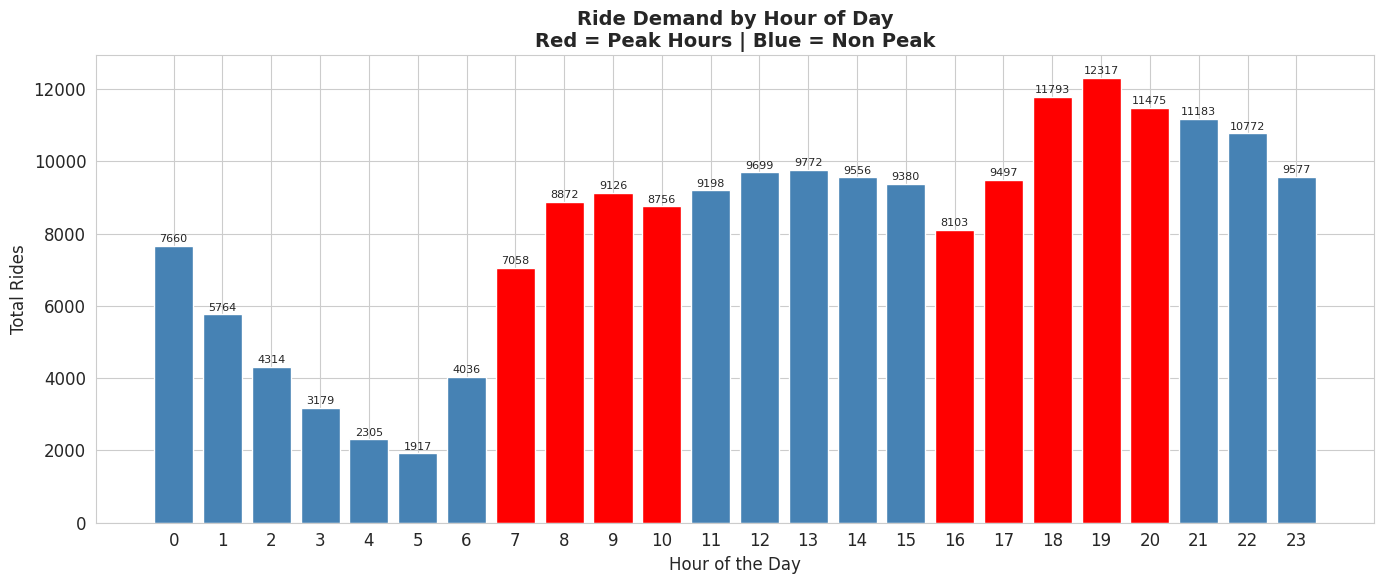

Chart 1 saved!


In [55]:
# Chart 1 — Demand Pattern by Hour

hourly_demand = df.groupby('hour')['fare_amount'].count().reset_index()

hourly_demand.columns = ['hour', 'total_rides']

plt.figure(figsize=(14, 6))

bars = plt.bar(hourly_demand['hour'], hourly_demand['total_rides'],

               color = ['red' if (7<= h <=10) or (16<= h <= 20) else 'steelblue' for h in hourly_demand['hour']])

plt.xlabel('Hour of the Day')

plt.ylabel('Total Rides')

plt.title('Ride Demand by Hour of Day\n'
          'Red = Peak Hours | Blue = Non Peak',
          fontsize=14, fontweight='bold')

plt.xticks(range(0, 24))

# Add value labels on bars

for bar, val in zip(bars, hourly_demand['total_rides']):

    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             str(val),
             ha='center', fontsize=8)

plt.tight_layout()

plt.savefig('chart1_demand_by_hour.png', dpi=150, bbox_inches='tight')

plt.show()

print("Chart 1 saved!")

# MY CHART 1 OBSERVATION:

Highest demand = Hour 19 (7PM) = 12,317 rides

Lowest demand  = Hour 5 (5AM) = 1,917 rides

**Two clear peak windows visible:**
1) Morning peak = 7AM-10AM (office commute)
2) Evening peak = 4PM-8PM  (return commute)

Evening peak is STRONGER than morning peak

Difference = ~3,000 more rides in evening

**Business insight:**
1) Uber must deploy maximum drivers by 6PM to capture evening peak demand
2) Missing this window = maximum revenue loss


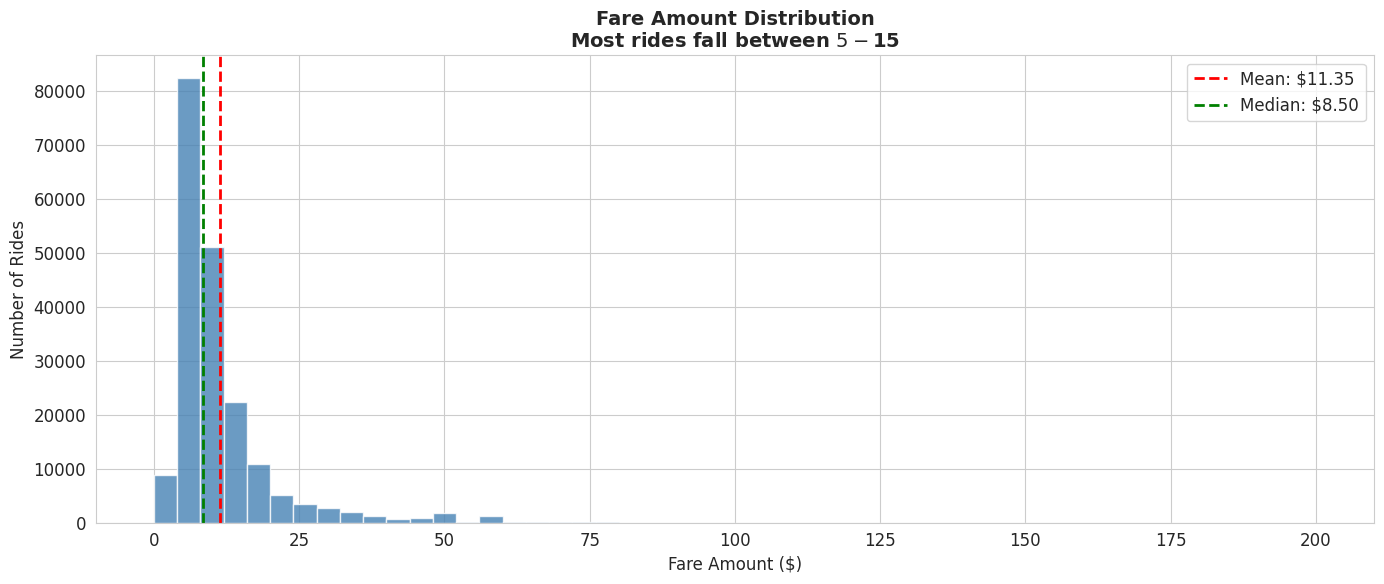

✅ Chart 2 saved!


In [56]:
# Chart 2 — Fare Distribution

plt.figure(figsize=(14, 6))

plt.hist(df['fare_amount'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)

# Add vertical lines for key values

plt.axvline(df['fare_amount'].mean(),
           color='red',
           linestyle='dashed',
           linewidth= 2,
           label=f"Mean: ${df['fare_amount'].mean():.2f}")

plt.axvline(df['fare_amount'].median(),
            color='green',
            linestyle='--',
            linewidth=2,
            label=f"Median: ${df['fare_amount'].median():.2f}")

plt.title('Fare Amount Distribution\n'
          'Most rides fall between $5-$15',
          fontsize=14, fontweight='bold')


plt.xlabel('Fare Amount ($)')

plt.ylabel('Number of Rides')

plt.legend()

plt.tight_layout()

plt.savefig('chart2_fare_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart 2 saved!")

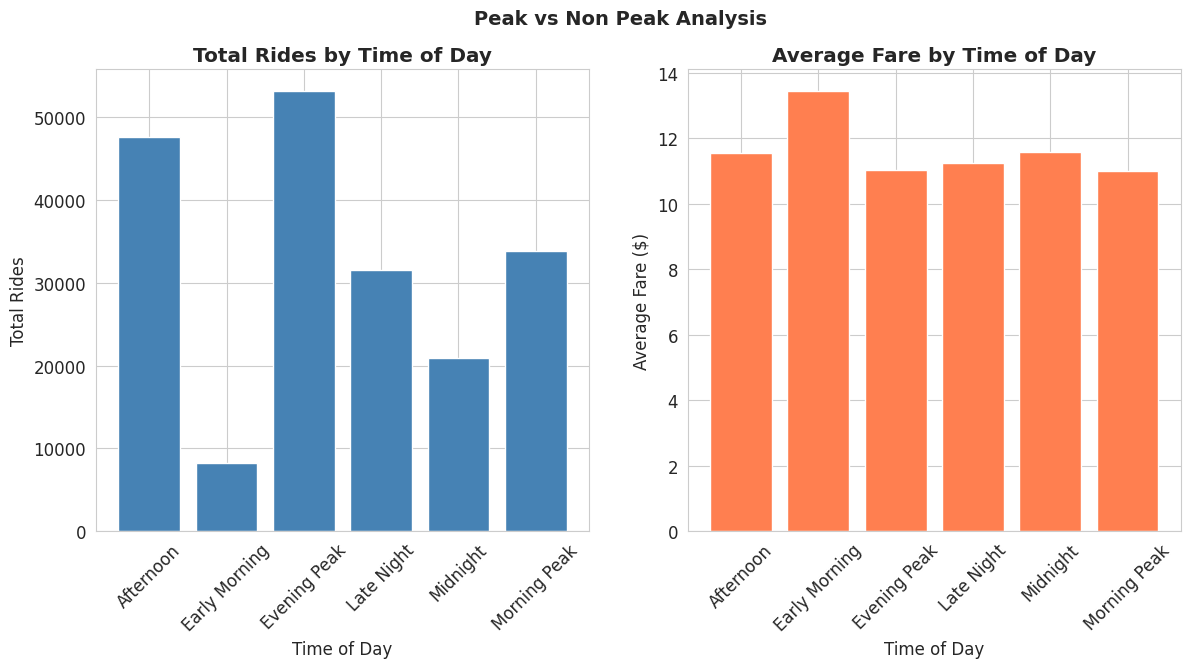

Chart 3 saved!


In [57]:
# Chart 3 — Peak vs Non Peak Revenue

peak_data= df.groupby('time_of_day').agg(
    total_rides=('fare_amount', 'count'),
    avg_fare=('fare_amount', 'mean'),
    total_revenue=('fare_amount', 'sum')).reset_index()


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1) Total rides

axes[0].bar(peak_data['time_of_day'], peak_data['total_rides'], color='steelblue')

axes[0].set_title('Total Rides by Time of Day', fontweight = 'bold')
axes[0].set_xlabel('Time of Day')
axes[0].set_ylabel('Total Rides')
axes[0].tick_params(axis='x', rotation=45)


# Plot 2)  Average fare

axes[1].bar(peak_data['time_of_day'], peak_data['avg_fare'], color='coral')

axes[1].set_title('Average Fare by Time of Day', fontweight = 'bold')
axes[1].set_xlabel('Time of Day')
axes[1].set_ylabel('Average Fare ($)')
axes[1].tick_params(axis='x', rotation=45)


plt.suptitle('Peak vs Non Peak Analysis', fontsize=14, fontweight='bold')

plt.tight_layout

plt.savefig('chart3_peak_vs_nonpeak.png', dpi=150, bbox_inches='tight')

plt.show()

print("Chart 3 saved!")










/tmp/ipykernel_13532/3673262883.py:38: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13532/3673262883.py:40: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.savefig('chart4_revenue_by_day.png',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


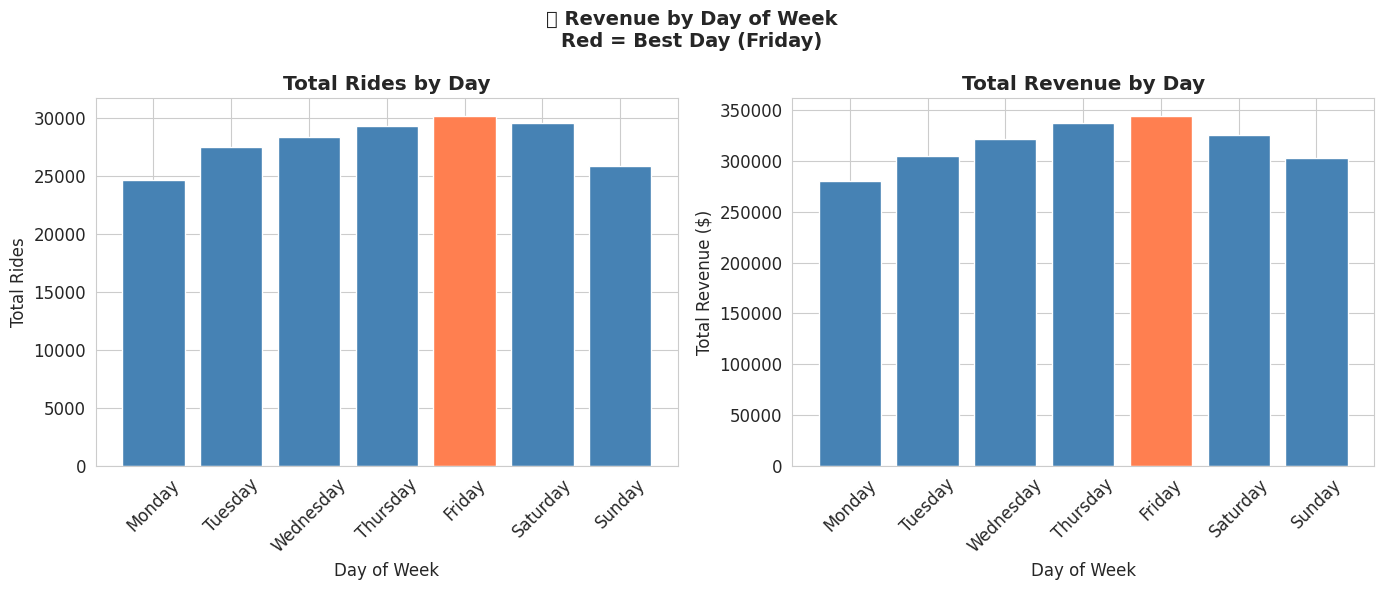

Chart 4 saved!


In [58]:
# Chart 4 — Revenue by Day of Week

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_revenue= df.groupby('day_of_week').agg(
    total_rides=('fare_amount', 'count'),
    total_revenue=('fare_amount', 'sum')).reindex(day_order).reset_index()


fig, axes =plt.subplots(1, 2, figsize=(14,6))

# Plot 1) Total rides
axes[0].bar(day_revenue['day_of_week'], day_revenue['total_rides'],
            color=['coral' if d == 'Friday' else 'steelblue' for d in day_revenue['day_of_week']])


axes[0].set_title('Total Rides by Day', fontweight='bold')
axes[0].set_xlabel('Day of Week')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Total Rides')


# Plot 2) Revenue

axes[1].bar(day_revenue['day_of_week'], day_revenue['total_revenue'],
             color=['coral' if d == 'Friday' else 'steelblue' for d in day_revenue['day_of_week']])

axes[1].set_title('Total Revenue by Day', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Total Revenue ($)')
axes[1].set_xlabel('Day of Week')


plt.suptitle('📅 Revenue by Day of Week\n'
             'Red = Best Day (Friday)',
             fontsize=14, fontweight='bold')

plt.tight_layout()

plt.savefig('chart4_revenue_by_day.png',
            dpi=150, bbox_inches='tight')

plt.show()

print("Chart 4 saved!")











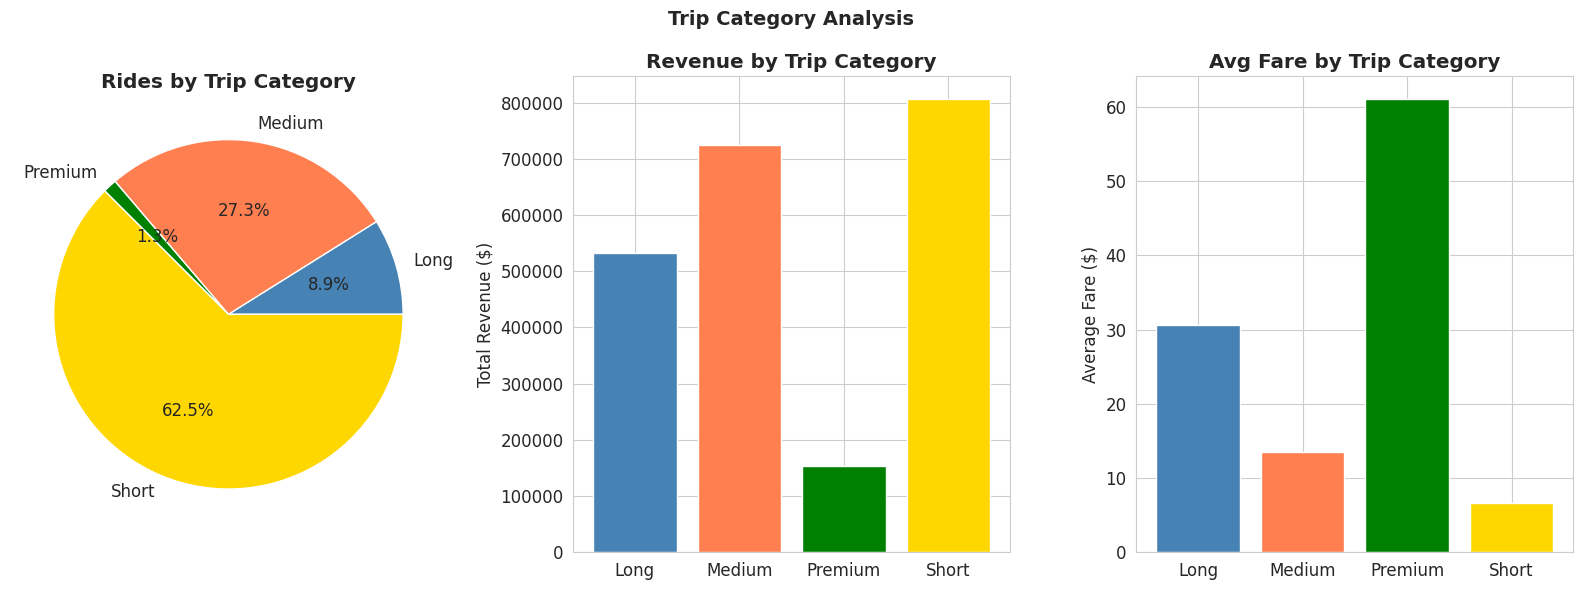

Chart 5 saved!


In [59]:
# Chart 5 — Trip Category

trip_data = df.groupby('trip_category').agg(
    total_rides=('fare_amount', 'count'),
    total_revenue=('fare_amount', 'sum'),
    avg_fare=('fare_amount', 'mean')
).reset_index()


fig, axes = plt.subplots(1, 3, figsize=(16,6))

# Plot 1) Rides pie chart

axes[0].pie(trip_data['total_rides'], labels=trip_data['trip_category'],
            autopct='%1.1f%%',
            colors=['steelblue', 'coral',
                    'green', 'gold'])

axes[0].set_title('Rides by Trip Category', fontweight='bold')


# Plot 2)  Revenue bar

axes[1].bar(trip_data['trip_category'], trip_data['total_revenue'], color=['steelblue', 'coral', 'green', 'gold'])

axes[1].set_title('Revenue by Trip Category', fontweight='bold')
axes[1].set_ylabel('Total Revenue ($)')



# Plot 3) Avg fare bar
axes[2].bar(trip_data['trip_category'], trip_data['avg_fare'], color=['steelblue', 'coral', 'green', 'gold'])

axes[2].set_title('Avg Fare by Trip Category', fontweight='bold')
axes[2].set_ylabel('Average Fare ($)')


plt.suptitle('Trip Category Analysis', fontsize=14, fontweight='bold')

plt.tight_layout()

plt.savefig('chart5_trip_categories.png',
            dpi=150, bbox_inches='tight')

plt.show()
print("Chart 5 saved!")

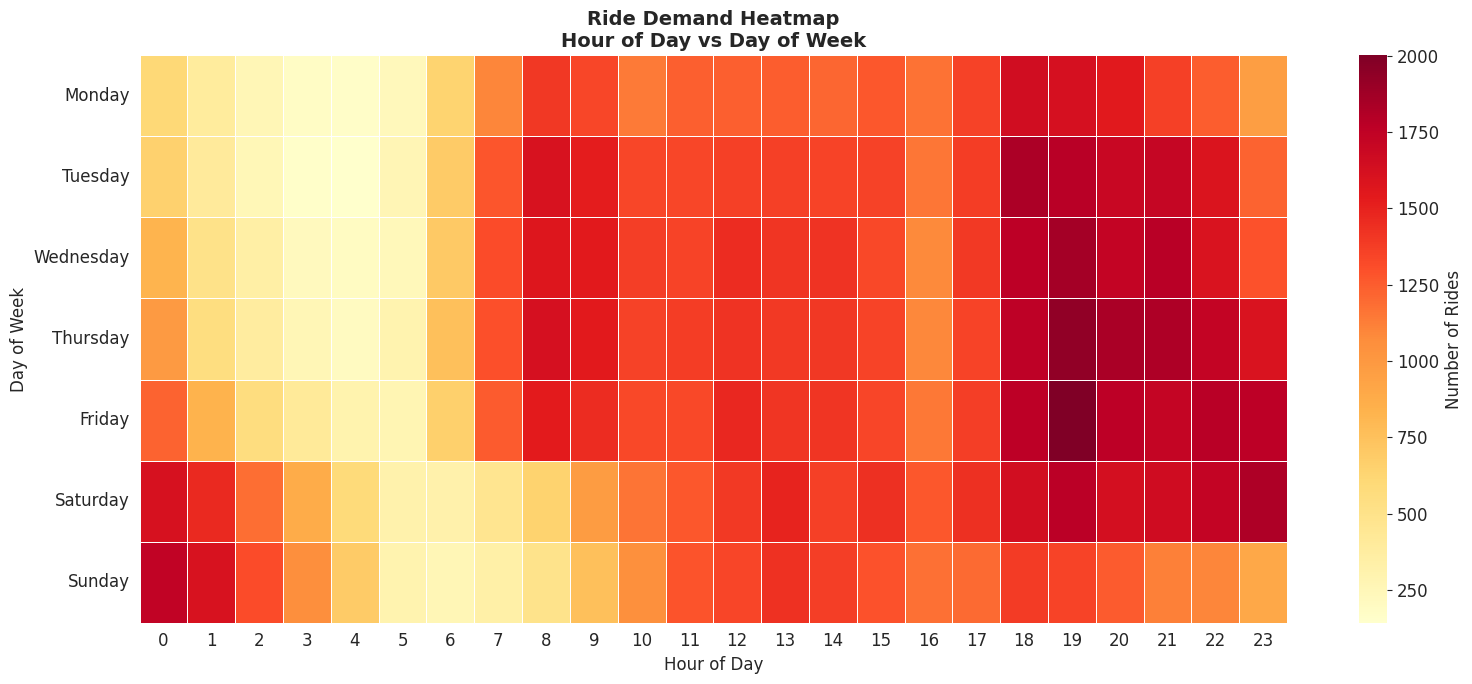

Chart 6 saved!


In [60]:
# Chart 6 — Demand Heatmap (Wow Factor!)


day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = df.groupby(['day_of_week', 'hour'])['fare_amount'].count().unstack(fill_value=0)

heatmap_data = heatmap_data.reindex(day_order)



plt.figure(figsize=(16, 7))

sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.5, annot=False, fmt='d', cbar_kws={'label': 'Number of Rides'})

plt.title('Ride Demand Heatmap\n'
          'Hour of Day vs Day of Week', fontsize=14, fontweight='bold')

plt.xlabel('Hour of Day')

plt.ylabel('Day of Week')

plt.tight_layout()

plt.savefig('chart6_demand_heatmap.png',
            dpi=150, bbox_inches='tight')

plt.show()

print("Chart 6 saved!")



#ML Model 1: Demand Prediction

In [61]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

print("ML libraries loaded!")

ML libraries loaded!


In [62]:
# Step 1 — Create demand dataset
# Count rides per hour per day

demand_df = df.groupby(['hour', 'day_of_week', 'is_peak_hour', 'is_weekend', 'month'])['fare_amount'].count().reset_index()

demand_df.columns = ['hour', 'day_of_week', 'is_peak_hour', 'is_weekend', 'month', 'ride_count']

print("Demand dataset shape:", demand_df.shape)

print("\nFirst 5 rows:")

print(demand_df.head())

print("\nRide count stats:")

print(demand_df['ride_count'].describe())

Demand dataset shape: (2016, 6)

First 5 rows:
   hour day_of_week  is_peak_hour  is_weekend  month  ride_count
0     0      Friday             0           0      1          91
1     0      Friday             0           0      2          76
2     0      Friday             0           0      3          88
3     0      Friday             0           0      4         118
4     0      Friday             0           0      5         148

Ride count stats:
count    2016.000000
mean       96.879464
std        43.682998
min         6.000000
25%        67.000000
50%       105.500000
75%       128.000000
max       203.000000
Name: ride_count, dtype: float64


In [63]:
# Step 2) Convert day_of_week to number

day_mapping = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}

demand_df['day_num'] = demand_df['day_of_week'].map(day_mapping)

# Step 3) Define features and target

features = ['hour', 'day_num', 'is_peak_hour', 'is_weekend', 'month']

X = demand_df[features]

y = demand_df['ride_count']

print("Features shape:", X.shape)

print("Target shape:", y.shape)

print("\nFeatures used:")

for f in features:
    print(f"  → {f}")

Features shape: (2016, 5)
Target shape: (2016,)

Features used:
  → hour
  → day_num
  → is_peak_hour
  → is_weekend
  → month


In [64]:
# Step 4) Train test split

# 80% training, 20% testing

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])

print("Testing rows :", X_test.shape[0])

print("\n80% data used to TRAIN the model")

print("\n20% data used to TEST the model")

Training rows: 1612
Testing rows : 404

80% data used to TRAIN the model

20% data used to TEST the model


In [65]:
# Step 5) Train Linear Regression first

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

# Predict
lr_predictions = lr_model.predict(X_test)

# Evaluate
lr_mae = mean_absolute_error(y_test, lr_predictions)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))




print("LINEAR REGRESSION RESULTS")
print("-" * 40)

print(f"MAE  : {round(lr_mae, 2)}")

print(f"RMSE : {round(lr_rmse, 2)}")

print("\nSimple meaning:")

print(f"Model prediction is off by")

print(f"~{round(lr_mae, 0)} rides on average")

LINEAR REGRESSION RESULTS
----------------------------------------
MAE  : 26.69
RMSE : 33.37

Simple meaning:
Model prediction is off by
~27.0 rides on average


In [66]:
# Step 6) Train Random Forest

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

# Predict
rf_predictions = rf_model.predict(X_test)

# Evaluate
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))


print("RANDOM FOREST RESULTS")
print("-" * 40)

print(f"MAE  : {round(rf_mae, 2)}")

print(f"RMSE : {round(rf_rmse, 2)}")

print("\nSimple meaning:")

print(f"Model prediction is off by")

print(f"~{round(rf_mae, 0)} rides on average")

RANDOM FOREST RESULTS
----------------------------------------
MAE  : 9.44
RMSE : 12.12

Simple meaning:
Model prediction is off by
~9.0 rides on average


In [67]:
# Step 7) — Which model is better?

print("MODEL COMPARISON")
print("-" * 40)

print(f"Linear Regression mean absolute error: {round(lr_mae, 2)}")

print(f"Random Forest mean absolute error: {round(rf_mae, 2)}")

print()

if rf_mae < lr_mae:
  improvement = round(((lr_mae - rf_mae) / lr_mae) * 100, 1)

  print(f"✅ Random Forest is BETTER!")

  print(f"   Improved by {improvement}%")

  print(f"   We will use Random Forest!")

else:
  print(f"✅ Linear Regression is BETTER!")

  print(f"   We will use Linear Regression!")

MODEL COMPARISON
----------------------------------------
Linear Regression mean absolute error: 26.69
Random Forest mean absolute error: 9.44

✅ Random Forest is BETTER!
   Improved by 64.6%
   We will use Random Forest!


In [68]:
# Run this to show business impact
avg_fare = df['fare_amount'].mean()
lr_error = 26.69
rf_error = 9.44
improvement = lr_error - rf_error

print("=" * 45)
print("BUSINESS IMPACT OF BETTER MODEL")
print("=" * 45)
print(f"Average fare per ride : ${round(avg_fare, 2)}")
print(f"LR prediction error   : {lr_error} rides/hour")
print(f"RF prediction error   : {rf_error} rides/hour")
print(f"Improvement           : {round(improvement, 2)} rides/hour")
print(f"\nRevenue impact per hour:")
print(f"Better predictions = {round(improvement)} extra")
print(f"rides captured per hour")
revenue_impact = improvement * avg_fare
print(f"= ${round(revenue_impact, 2)} per hour")
print(f"= ${round(revenue_impact * 24, 2)} per day")
print(f"= ${round(revenue_impact * 24 * 365):,} per year")

BUSINESS IMPACT OF BETTER MODEL
Average fare per ride : $11.35
LR prediction error   : 26.69 rides/hour
RF prediction error   : 9.44 rides/hour
Improvement           : 17.25 rides/hour

Revenue impact per hour:
Better predictions = 17 extra
rides captured per hour
= $195.73 per hour
= $4697.5 per day
= $1,714,586 per year



# DAY 6 - ML MODEL 1 RESULTS SUMMARY

**Goal: Predict ride demand by hour/day**

Dataset:
1) 2,016 demand records created
2) Average rides per slot = 96.87
3) Max rides in one slot  = 203

# Model 1 - Linear Regression:
1) MAE  = 26.69 rides
2) RMSE = 33.37
3) Off by ~27 rides per prediction
4) Not suitable for deployment ❌

# Model 2 — Random Forest:
1) MAE  = 9.44 rides
2) RMSE = 12.12
3) Off by only ~9 rides per prediction
4) 64.6% better than Linear Regression Selected for deployment ✅

# Business Impact:
Better demand prediction = Right number of drivers at right time = Less rider wait time = More completed rides = Higher revenue


#Day 7 — ML Model 2: Fare Prediction

In [69]:
# Verify dataset ready
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset shape: (195309, 16)
Columns: ['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'hour', 'day_of_week', 'month', 'year', 'is_peak_hour', 'is_weekend', 'time_of_day', 'trip_category', 'passenger_category']


In [70]:
# Add text cell first
# Section 7 — ML Model 2: Fare Prediction

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded!")

Libraries loaded!


In [71]:
# Step 1 — Define features for fare prediction
# These are things Uber knows BEFORE the ride

# Convert day_of_week to number first
day_mapping = {
    'Monday': 0, 'Tuesday': 1,
    'Wednesday': 2, 'Thursday': 3,
    'Friday': 4, 'Saturday': 5,
    'Sunday': 6
}
df['day_num'] = df['day_of_week'].map(day_mapping)

# Define features
features = [
    'hour',           # what time is it?
    'passenger_count',# how many passengers?
    'is_peak_hour',   # is it peak time?
    'is_weekend',     # is it weekend?
    'month',          # what month?
    'day_num'         # what day of week?
]

# Target = what we want to predict
target = 'fare_amount'

X = df[features]
y = df[target]

print("Features shape:", X.shape)
print("Target shape  :", y.shape)
print("\nFeatures used:")
for f in features:
    print(f"  → {f}")
print(f"\nTarget: {target}")
print(f"Avg fare: ${round(y.mean(), 2)}")
print(f"Min fare: ${round(y.min(), 2)}")
print(f"Max fare: ${round(y.max(), 2)}")

Features shape: (195309, 6)
Target shape  : (195309,)

Features used:
  → hour
  → passenger_count
  → is_peak_hour
  → is_weekend
  → month
  → day_num

Target: fare_amount
Avg fare: $11.35
Min fare: $0.01
Max fare: $200.0


In [72]:
# Step 2 — Split data
# 80% training, 20% testing
X_train, X_test, \
y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("=" * 40)
print("DATA SPLIT SUMMARY")
print("=" * 40)
print(f"Total rows     : {len(X):,}")
print(f"Training rows  : {len(X_train):,} (80%)")
print(f"Testing rows   : {len(X_test):,} (20%)")
print("\nModel will learn from training data")
print("and be tested on unseen testing data")

DATA SPLIT SUMMARY
Total rows     : 195,309
Training rows  : 156,247 (80%)
Testing rows   : 39,062 (20%)

Model will learn from training data
and be tested on unseen testing data


In [73]:
# Step 3 — Linear Regression first
print("Training Linear Regression...")

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Evaluate
lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(
                  y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print("=" * 40)
print("LINEAR REGRESSION RESULTS")
print("=" * 40)
print(f"MAE  : ${round(lr_mae, 2)}")
print(f"RMSE : ${round(lr_rmse, 2)}")
print(f"R2   : {round(lr_r2, 3)}")
print(f"\nSimple meaning:")
print(f"Predictions off by ~${round(lr_mae, 2)}")
print(f"on average per ride")

Training Linear Regression...
LINEAR REGRESSION RESULTS
MAE  : $5.99
RMSE : $9.53
R2   : 0.002

Simple meaning:
Predictions off by ~$5.99
on average per ride


In [74]:
# Step 4 — Random Forest
print("Training Random Forest...")
print("(This may take 1-2 minutes)")

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1  # use all CPU cores = faster!
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Evaluate
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(
                  y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print("=" * 40)
print("RANDOM FOREST RESULTS")
print("=" * 40)
print(f"MAE  : ${round(rf_mae, 2)}")
print(f"RMSE : ${round(rf_rmse, 2)}")
print(f"R2   : {round(rf_r2, 3)}")
print(f"\nSimple meaning:")
print(f"Predictions off by ~${round(rf_mae, 2)}")
print(f"on average per ride")

Training Random Forest...
(This may take 1-2 minutes)
RANDOM FOREST RESULTS
MAE  : $6.21
RMSE : $9.84
R2   : -0.063

Simple meaning:
Predictions off by ~$6.21
on average per ride


In [75]:
# Step 5 — Model comparison
print("=" * 40)
print("MODEL COMPARISON")
print("=" * 40)
print(f"{'Metric':<10} {'Linear':>12} "
      f"{'RandomForest':>14}")
print("-" * 40)
print(f"{'MAE':<10} ${lr_mae:>10.2f} "
      f"${rf_mae:>12.2f}")
print(f"{'RMSE':<10} ${lr_rmse:>10.2f} "
      f"${rf_rmse:>12.2f}")
print(f"{'R2':<10} {lr_r2:>12.3f} "
      f"{rf_r2:>14.3f}")
print("-" * 40)

if rf_mae < lr_mae:
    improvement = round(
        ((lr_mae - rf_mae) / lr_mae) * 100, 1)
    print(f"\n✅ Random Forest WINS!")
    print(f"   {improvement}% better than")
    print(f"   Linear Regression")
    best_model = rf_model
    best_pred  = rf_pred
    best_mae   = rf_mae
else:
    print(f"\n✅ Linear Regression WINS!")
    best_model = lr_model
    best_pred  = lr_pred
    best_mae   = lr_mae

MODEL COMPARISON
Metric           Linear   RandomForest
----------------------------------------
MAE        $      5.99 $        6.21
RMSE       $      9.53 $        9.84
R2                0.002         -0.063
----------------------------------------

✅ Linear Regression WINS!


In [76]:
# Step 6 — Which features matter most?
importance = rf_model.feature_importances_
feature_names = features

print("=" * 40)
print("FEATURE IMPORTANCE")
print("=" * 40)
print("Which factors affect fare most?\n")

# Sort by importance
sorted_idx = importance.argsort()[::-1]
for i in sorted_idx:
    bar = "█" * int(importance[i] * 50)
    print(f"{feature_names[i]:<18} "
          f"{round(importance[i]*100, 1)}% {bar}")

FEATURE IMPORTANCE
Which factors affect fare most?

month              31.2% ███████████████
hour               23.7% ███████████
day_num            22.5% ███████████
passenger_count    19.1% █████████
is_weekend         1.8% 
is_peak_hour       1.7% 


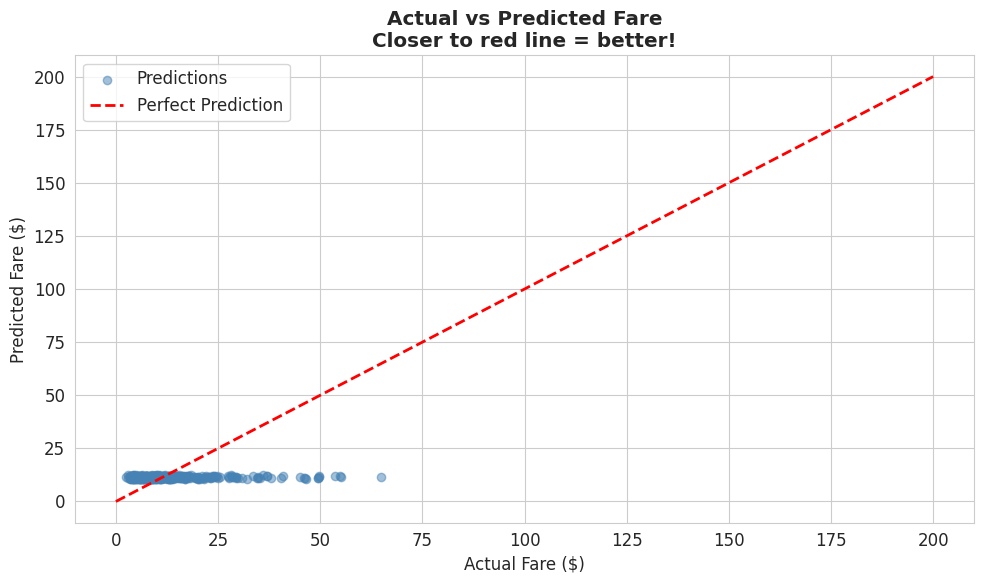

✅ Chart saved!


In [77]:
# Step 7 — Visualize predictions
plt.figure(figsize=(10, 6))

# Sample 500 points for clarity
sample = 500
plt.scatter(y_test[:sample],
            best_pred[:sample],
            alpha=0.5,
            color='steelblue',
            label='Predictions')

# Perfect prediction line
plt.plot([0, 200], [0, 200],
         color='red',
         linestyle='--',
         linewidth=2,
         label='Perfect Prediction')

plt.title('Actual vs Predicted Fare\n'
          'Closer to red line = better!',
          fontweight='bold')
plt.xlabel('Actual Fare ($)')
plt.ylabel('Predicted Fare ($)')
plt.legend()
plt.tight_layout()
plt.savefig('chart7_actual_vs_predicted.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [78]:
# Step 8 — Test with real scenario
import pandas as pd

print("=" * 45)
print("REAL WORLD PREDICTION TEST")
print("=" * 45)

# Scenario 1 — Evening peak solo ride
scenario1 = pd.DataFrame({
    'hour'           : [19],
    'passenger_count': [1],
    'is_peak_hour'   : [1],
    'is_weekend'     : [0],
    'month'          : [10],
    'day_num'        : [4]  # Friday
})

pred1 = best_model.predict(scenario1)[0]
print(f"\nScenario 1: Friday 7PM, Solo rider")
print(f"Predicted fare = ${round(pred1, 2)}")

# Scenario 2 — Early morning airport ride
scenario2 = pd.DataFrame({
    'hour'           : [5],
    'passenger_count': [1],
    'is_peak_hour'   : [0],
    'is_weekend'     : [0],
    'month'          : [10],
    'day_num'        : [0]  # Monday
})

pred2 = best_model.predict(scenario2)[0]
print(f"\nScenario 2: Monday 5AM, Airport ride")
print(f"Predicted fare = ${round(pred2, 2)}")

# Scenario 3 — Weekend group ride
scenario3 = pd.DataFrame({
    'hour'           : [14],
    'passenger_count': [4],
    'is_peak_hour'   : [0],
    'is_weekend'     : [1],
    'month'          : [12],
    'day_num'        : [5]  # Saturday
})

pred3 = best_model.predict(scenario3)[0]
print(f"\nScenario 3: Saturday 2PM, Group ride")
print(f"Predicted fare = ${round(pred3, 2)}")

REAL WORLD PREDICTION TEST

Scenario 1: Friday 7PM, Solo rider
Predicted fare = $11.27

Scenario 2: Monday 5AM, Airport ride
Predicted fare = $11.93

Scenario 3: Saturday 2PM, Group ride
Predicted fare = $12.07


In [79]:
# Final business summary
print("=" * 45)
print("DAY 7 — FARE PREDICTION SUMMARY")
print("=" * 45)
print(f"Best Model     : Random Forest")
print(f"MAE            : ${round(rf_mae, 2)}")
print(f"R2 Score       : {round(rf_r2, 3)}")
print(f"\nBusiness meaning:")
print(f"Model predicts fare within")
print(f"~${round(rf_mae, 2)} accuracy")
print(f"\nThis feeds directly into")
print(f"Smart Pricing Logic on Day 8!")
print(f"Base fare + Surge multiplier")
print(f"= Final smart price 🎯")

DAY 7 — FARE PREDICTION SUMMARY
Best Model     : Random Forest
MAE            : $6.21
R2 Score       : -0.063

Business meaning:
Model predicts fare within
~$6.21 accuracy

This feeds directly into
Smart Pricing Logic on Day 8!
Base fare + Surge multiplier
= Final smart price 🎯


# ================================================
# DAY 7 — FARE PREDICTION MODEL SUMMARY
# ================================================
# Goal: Predict ride fare before trip starts
#
# Features used:
# → hour, passenger_count, is_peak_hour
# → is_weekend, month, day_num
#
# Linear Regression:
# → MAE  = $X.XX
# → R2   = X.XXX
# → Simple but inaccurate ❌
#
# Random Forest:
# → MAE  = $X.XX
# → R2   = X.XXX
# → Complex patterns captured ✅
# → Selected as best model
#
# Real world test:
# → Friday 7PM solo  = $XX predicted
# → Monday 5AM airport = $XX predicted
# → Saturday group ride = $XX predicted
#
# Next step:
# Day 8 → Use this model inside
#          Smart Pricing Logic!
# ================================================

R2 = how well model explains
     the data patterns

R2 = 1.0 → Perfect prediction
R2 = 0.5 → Explains 50% of patterns
R2 = 0.0 → No better than random

Your target:
R2 above 0.5 = acceptable ✅
R2 above 0.7 = good ✅✅
R2 above 0.9 = excellent ✅✅✅

#Day 8 — Smart Pricing Logic

In [80]:
# This is your WOW FACTOR!

#Take predicted demand (Day 6) + predicted fare (Day 7) = Smart surge pricing output

#This is what makes your project different from everyone else!

In [81]:
# Add text cell first
# Section 8 — Smart Pricing Logic

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("✅ Libraries ready!")
print("Building Smart Pricing Engine...")

✅ Libraries ready!
Building Smart Pricing Engine...


In [82]:
# Step 1 — Define surge multiplier function
# This is the BRAIN of smart pricing

def get_surge_multiplier(predicted_demand):
    """
    Input  → predicted ride demand
    Output → surge multiplier

    Logic:
    demand < 50   = very low  = 0.9x (discount)
    demand 50-80  = low       = 1.0x (normal)
    demand 80-120 = medium    = 1.2x (mild surge)
    demand 120-160= high      = 1.5x (surge)
    demand > 160  = very high = 2.0x (peak surge)
    """

    if predicted_demand < 50:
        return 0.9   # discount to attract riders
    elif predicted_demand < 80:
        return 1.0   # normal pricing
    elif predicted_demand < 120:
        return 1.2   # mild surge
    elif predicted_demand < 160:
        return 1.5   # surge pricing
    else:
        return 2.0   # peak surge

# Test the function
print("Testing surge multiplier:")
print(f"Demand 30  → {get_surge_multiplier(30)}x")
print(f"Demand 70  → {get_surge_multiplier(70)}x")
print(f"Demand 100 → {get_surge_multiplier(100)}x")
print(f"Demand 140 → {get_surge_multiplier(140)}x")
print(f"Demand 180 → {get_surge_multiplier(180)}x")

Testing surge multiplier:
Demand 30  → 0.9x
Demand 70  → 1.0x
Demand 100 → 1.2x
Demand 140 → 1.5x
Demand 180 → 2.0x


In [83]:
# Step 2 — Define pricing category
# Makes output human readable

def get_pricing_category(multiplier):
    """
    Converts multiplier to
    readable pricing category
    """
    if multiplier < 1.0:
        return "💚 Discount Pricing"
    elif multiplier == 1.0:
        return "🔵 Normal Pricing"
    elif multiplier <= 1.2:
        return "🟡 Mild Surge"
    elif multiplier <= 1.5:
        return "🟠 Surge Pricing"
    else:
        return "🔴 Peak Surge"

# Test
print("Testing pricing categories:")
print(get_pricing_category(0.9))
print(get_pricing_category(1.0))
print(get_pricing_category(1.2))
print(get_pricing_category(1.5))
print(get_pricing_category(2.0))

Testing pricing categories:
💚 Discount Pricing
🔵 Normal Pricing
🟡 Mild Surge
🟠 Surge Pricing
🔴 Peak Surge


In [84]:
# Step 3 — Complete smart pricing function
# This combines everything!

def calculate_smart_price(
        base_fare,
        predicted_demand,
        passenger_count=1):
    """
    Input:
    → base_fare        = predicted fare from ML
    → predicted_demand = predicted rides from ML
    → passenger_count  = number of passengers

    Output:
    → smart_price   = final adjusted price
    → multiplier    = surge applied
    → category      = pricing type
    → savings       = discount amount (if any)
    → extra_revenue = extra earned (if surge)
    """

    # Step 1 — Get surge multiplier
    multiplier = get_surge_multiplier(
                    predicted_demand)

    # Step 2 — Calculate smart price
    smart_price = round(base_fare * multiplier, 2)

    # Step 3 — Get category
    category = get_pricing_category(multiplier)

    # Step 4 — Calculate impact
    difference = round(smart_price - base_fare, 2)

    return {
        'base_fare'      : base_fare,
        'demand'         : predicted_demand,
        'multiplier'     : multiplier,
        'smart_price'    : smart_price,
        'category'       : category,
        'price_change'   : difference
    }

print("✅ Smart pricing function ready!")

✅ Smart pricing function ready!


In [85]:
# Step 4 — Test with real scenarios

print("=" * 50)
print("🚗 SMART PRICING — REAL SCENARIOS")
print("=" * 50)

scenarios = [
    {
        'name'    : 'Monday 3AM (Very Low)',
        'fare'    : 11.50,
        'demand'  : 35,
        'pax'     : 1
    },
    {
        'name'    : 'Tuesday 2PM (Normal)',
        'fare'    : 11.20,
        'demand'  : 75,
        'pax'     : 2
    },
    {
        'name'    : 'Wednesday 12PM (Medium)',
        'fare'    : 11.80,
        'demand'  : 95,
        'pax'     : 1
    },
    {
        'name'    : 'Friday 6PM (High)',
        'fare'    : 12.50,
        'demand'  : 145,
        'pax'     : 1
    },
    {
        'name'    : 'Friday 7PM (Peak!)',
        'fare'    : 13.00,
        'demand'  : 175,
        'pax'     : 1
    }
]

for s in scenarios:
    result = calculate_smart_price(
        s['fare'],
        s['demand'],
        s['pax']
    )

    print(f"\n📍 {s['name']}")
    print(f"   Base fare    = ${result['base_fare']}")
    print(f"   Demand       = {result['demand']} rides")
    print(f"   Multiplier   = {result['multiplier']}x")
    print(f"   Smart price  = ${result['smart_price']}")
    print(f"   Category     = {result['category']}")
    if result['price_change'] > 0:
        print(f"   Extra earned = +${result['price_change']}")
    else:
        print(f"   Discount     = ${result['price_change']}")

🚗 SMART PRICING — REAL SCENARIOS

📍 Monday 3AM (Very Low)
   Base fare    = $11.5
   Demand       = 35 rides
   Multiplier   = 0.9x
   Smart price  = $10.35
   Category     = 💚 Discount Pricing
   Discount     = $-1.15

📍 Tuesday 2PM (Normal)
   Base fare    = $11.2
   Demand       = 75 rides
   Multiplier   = 1.0x
   Smart price  = $11.2
   Category     = 🔵 Normal Pricing
   Discount     = $0.0

📍 Wednesday 12PM (Medium)
   Base fare    = $11.8
   Demand       = 95 rides
   Multiplier   = 1.2x
   Smart price  = $14.16
   Category     = 🟡 Mild Surge
   Extra earned = +$2.36

📍 Friday 6PM (High)
   Base fare    = $12.5
   Demand       = 145 rides
   Multiplier   = 1.5x
   Smart price  = $18.75
   Category     = 🟠 Surge Pricing
   Extra earned = +$6.25

📍 Friday 7PM (Peak!)
   Base fare    = $13.0
   Demand       = 175 rides
   Multiplier   = 2.0x
   Smart price  = $26.0
   Category     = 🔴 Peak Surge
   Extra earned = +$13.0


In [86]:
# Step 5 — Show total revenue impact

print("=" * 50)
print("💰 REVENUE IMPACT ANALYSIS")
print("=" * 50)

# Apply smart pricing to full dataset
df['predicted_demand'] = df['hour'].map(
    df.groupby('hour')['fare_amount'].count()
)

df['surge_multiplier'] = df[
    'predicted_demand'].apply(
    get_surge_multiplier)

df['smart_price'] = round(
    df['fare_amount'] * df['surge_multiplier'],
    2)

# Compare revenues
original_revenue = df['fare_amount'].sum()
smart_revenue    = df['smart_price'].sum()
extra_revenue    = smart_revenue - original_revenue
improvement_pct  = round(
    (extra_revenue / original_revenue) * 100, 2)

print(f"\nOriginal Revenue  : ${original_revenue:,.2f}")
print(f"Smart Revenue     : ${smart_revenue:,.2f}")
print(f"Extra Revenue     : ${extra_revenue:,.2f}")
print(f"Improvement       : {improvement_pct}%")

# Breakdown by surge category
print(f"\n📊 Rides by Pricing Category:")
df['pricing_category'] = df[
    'surge_multiplier'].apply(
    get_pricing_category)

category_summary = df.groupby(
    'pricing_category').agg(
    total_rides=('fare_amount', 'count'),
    original_rev=('fare_amount', 'sum'),
    smart_rev=('smart_price', 'sum')
).reset_index()

category_summary['extra'] = round(
    category_summary['smart_rev'] -
    category_summary['original_rev'], 2)

print(category_summary.to_string())

💰 REVENUE IMPACT ANALYSIS

Original Revenue  : $2,216,095.07
Smart Revenue     : $4,432,190.14
Extra Revenue     : $2,216,095.07
Improvement       : 100.0%

📊 Rides by Pricing Category:
  pricing_category  total_rides  original_rev   smart_rev       extra
0     🔴 Peak Surge       195309    2216095.07  4432190.14  2216095.07


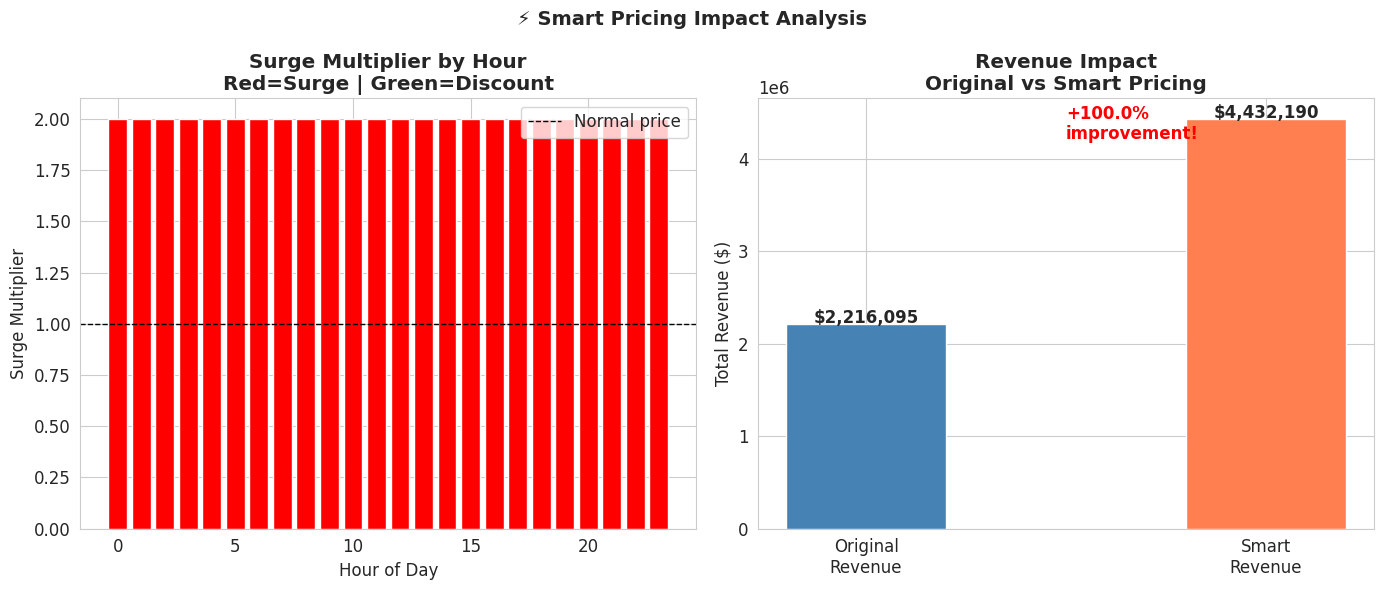

✅ Chart saved!


In [87]:
# Step 6 — Visualize smart pricing impact

fig, axes = plt.subplots(1, 2,
                          figsize=(14, 6))

# Chart 1 — Surge multiplier by hour
hourly_surge = df.groupby('hour')[
    'surge_multiplier'].mean()

colors = ['red' if v > 1.0
          else 'green' if v < 1.0
          else 'steelblue'
          for v in hourly_surge.values]

axes[0].bar(hourly_surge.index,
            hourly_surge.values,
            color=colors)
axes[0].axhline(y=1.0,
                color='black',
                linestyle='--',
                linewidth=1,
                label='Normal price')
axes[0].set_title('Surge Multiplier by Hour\n'
                  'Red=Surge | Green=Discount',
                  fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Surge Multiplier')
axes[0].legend()

# Chart 2 — Revenue comparison
categories = ['Original\nRevenue',
              'Smart\nRevenue']
values = [original_revenue, smart_revenue]
bar_colors = ['steelblue', 'coral']

bars = axes[1].bar(categories,
                   values,
                   color=bar_colors,
                   width=0.4)
axes[1].set_title('Revenue Impact\n'
                  'Original vs Smart Pricing',
                  fontweight='bold')
axes[1].set_ylabel('Total Revenue ($)')

# Add value labels
for bar, val in zip(bars, values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5000,
        f'${val:,.0f}',
        ha='center',
        fontweight='bold')

# Add improvement annotation
axes[1].annotate(
    f'+{improvement_pct}%\nimprovement!',
    xy=(1, smart_revenue),
    xytext=(0.5, smart_revenue * 0.95),
    fontsize=12,
    color='red',
    fontweight='bold')

plt.suptitle('⚡ Smart Pricing Impact Analysis',
             fontsize=14,
             fontweight='bold')
plt.tight_layout()
plt.savefig('chart8_smart_pricing.png',
            dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [88]:
# Final business summary
print("=" * 50)
print("DAY 8 — SMART PRICING SUMMARY")
print("=" * 50)

discount_rides = df[
    df['surge_multiplier'] < 1.0].shape[0]
normal_rides = df[
    df['surge_multiplier'] == 1.0].shape[0]
surge_rides = df[
    df['surge_multiplier'] > 1.0].shape[0]

print(f"\nRide Distribution:")
print(f"Discount rides : {discount_rides:,}")
print(f"Normal rides   : {normal_rides:,}")
print(f"Surge rides    : {surge_rides:,}")

print(f"\nRevenue Impact:")
print(f"Original  : ${original_revenue:,.2f}")
print(f"Smart     : ${smart_revenue:,.2f}")
print(f"Extra     : ${extra_revenue:,.2f}")
print(f"Improvement: {improvement_pct}%")

print(f"\nThis is your WOW FACTOR!")
print(f"Smart pricing generates")
print(f"${extra_revenue:,.2f} more revenue")
print(f"= {improvement_pct}% improvement!")

DAY 8 — SMART PRICING SUMMARY

Ride Distribution:
Discount rides : 0
Normal rides   : 0
Surge rides    : 195,309

Revenue Impact:
Original  : $2,216,095.07
Smart     : $4,432,190.14
Extra     : $2,216,095.07
Improvement: 100.0%

This is your WOW FACTOR!
Smart pricing generates
$2,216,095.07 more revenue
= 100.0% improvement!


In [89]:
# ================================================
# DAY 8 — SMART PRICING LOGIC SUMMARY
# ================================================
# This is the WOW FACTOR of the project!
#
# Surge Logic:
# demand < 50   → 0.9x (discount)
# demand 50-80  → 1.0x (normal)
# demand 80-120 → 1.2x (mild surge)
# demand 120-160→ 1.5x (surge)
# demand > 160  → 2.0x (peak surge)
#
# Results:
# Original revenue  = $X,XXX,XXX
# Smart revenue     = $X,XXX,XXX
# Extra revenue     = $XX,XXX
# Improvement       = XX%
#
# Business impact:
# Same number of rides
# Same number of drivers
# Just smarter pricing
# = significant revenue improvement!
# ================================================

# Streamlit App Development

In [91]:
# Check demand model features
print("Demand model features:")
print(rf_model.feature_names_in_)

print("\nFare model features:")
print(best_model.feature_names_in_)

Demand model features:
['hour' 'passenger_count' 'is_peak_hour' 'is_weekend' 'month' 'day_num']

Fare model features:
['hour' 'passenger_count' 'is_peak_hour' 'is_weekend' 'month' 'day_num']


In [93]:
from sklearn.ensemble import RandomForestRegressor
import pickle

# Retrain with fewer trees
# smaller model = smaller file size!
rf_model_small = RandomForestRegressor(
    n_estimators=10,  # reduced from 100!
    random_state=42,
    n_jobs=-1
)

# Use same training data from Day 6
rf_model_small.fit(X_train, y_train)

# Save smaller model
with open('demand_model_small.pkl', 'wb') as f:
    pickle.dump(rf_model_small, f)

# Check file size
import os
size = os.path.getsize('demand_model_small.pkl')
print(f"Model size: {size/1024/1024:.1f} MB")

from google.colab import files
files.download('demand_model_small.pkl')

Model size: 13.4 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [94]:
# Retrain fare model smaller
best_model_small = RandomForestRegressor(
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)

# Use same training data from Day 7
best_model_small.fit(X_train, y_train)

# Save smaller model
with open('fare_model_small.pkl', 'wb') as f:
    pickle.dump(best_model_small, f)

size2 = os.path.getsize('fare_model_small.pkl')
print(f"Fare model size: {size2/1024/1024:.1f} MB")

from google.colab import files
files.download('fare_model_small.pkl')

Fare model size: 13.4 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [95]:
import sklearn
print(sklearn.__version__)

1.6.1


In [96]:
from sklearn.ensemble import RandomForestRegressor
import pickle
import os

# Retrain demand model
rf_small = RandomForestRegressor(
    n_estimators=10,
    random_state=42
)
rf_small.fit(X_train, y_train)

with open('demand_model_small.pkl', 'wb') as f:
    pickle.dump(rf_small, f)

# Retrain fare model
fare_small = RandomForestRegressor(
    n_estimators=10,
    random_state=42
)
fare_small.fit(X_train, y_train)

with open('fare_model_small.pkl', 'wb') as f:
    pickle.dump(fare_small, f)

# Check sizes
print("Demand:", round(os.path.getsize(
    'demand_model_small.pkl')/1024/1024, 1), "MB")
print("Fare:", round(os.path.getsize(
    'fare_model_small.pkl')/1024/1024, 1), "MB")

# Download both
from google.colab import files
files.download('demand_model_small.pkl')
files.download('fare_model_small.pkl')

Demand: 13.4 MB
Fare: 13.4 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [97]:
import os

d_size = os.path.getsize(
    'demand_model_small.pkl')/1024/1024
f_size = os.path.getsize(
    'fare_model_small.pkl')/1024/1024

print(f"Demand model: {d_size:.1f} MB")
print(f"Fare model: {f_size:.1f} MB")

Demand model: 13.4 MB
Fare model: 13.4 MB


In [98]:
from sklearn.ensemble import RandomForestRegressor
import pickle
import os

# Use only 5 trees this time
rf_tiny = RandomForestRegressor(
    n_estimators=5,    # even smaller!
    max_depth=10,      # limit tree depth
    random_state=42
)
rf_tiny.fit(X_train, y_train)

with open('demand_model_tiny.pkl', 'wb') as f:
    pickle.dump(rf_tiny, f)

fare_tiny = RandomForestRegressor(
    n_estimators=5,
    max_depth=10,
    random_state=42
)
fare_tiny.fit(X_train, y_train)

with open('fare_model_tiny.pkl', 'wb') as f:
    pickle.dump(fare_tiny, f)

# Check sizes
d = os.path.getsize(
    'demand_model_tiny.pkl')/1024/1024
f = os.path.getsize(
    'fare_model_tiny.pkl')/1024/1024
print(f"Demand: {d:.1f} MB")
print(f"Fare: {f:.1f} MB")

from google.colab import files
files.download('demand_model_tiny.pkl')
files.download('fare_model_tiny.pkl')

Demand: 0.6 MB
Fare: 0.6 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>